## Install packages

In [5]:
pip install pandas numpy matplotlib seaborn scikit-learn xgboost joblib requests

Note: you may need to restart the kernel to use updated packages.


In [6]:
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

warnings.filterwarnings("ignore")

RANDOM_STATE = 42

BASE_DIR = Path("..")
RAW_DIR = BASE_DIR / "data" / "raw" / "ml-32m"
PROCESSED_DIR = BASE_DIR / "data" / "processed"
MODEL_DIR = BASE_DIR / "models"
OUTPUT_DIR = BASE_DIR / "outputs"

PROCESSED_DIR.mkdir(parents=True, exist_ok=True)
MODEL_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print("STREAMIQ environment ready.")
print("Raw data path:", RAW_DIR)

STREAMIQ environment ready.
Raw data path: ..\data\raw\ml-32m


In [7]:
movies = pd.read_csv(RAW_DIR / "movies.csv")
links = pd.read_csv(RAW_DIR / "links.csv")

print("Movies shape:", movies.shape)
print("Links shape:", links.shape)

display(movies.head())
display(links.head())

Movies shape: (87585, 3)
Links shape: (87585, 3)


,movieId,title,genres
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,2,Jumanji (1995),Adventure|Children|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance
4,5,Father of the Bride Part II (1995),Comedy


,movieId,imdbId,tmdbId
0,1,114709,862.0
1,2,113497,8844.0
2,3,113228,15602.0
3,4,114885,31357.0
4,5,113041,11862.0


In [8]:
ratings = pd.read_csv(
    RAW_DIR / "ratings.csv",
    dtype={
        "userId": "int32",
        "movieId": "int32",
        "rating": "float32",
        "timestamp": "int64"
    }
)

print("Ratings shape:", ratings.shape)
display(ratings.head())

Ratings shape: (32000204, 4)


,userId,movieId,rating,timestamp
0,1,17,4.0,944249077
1,1,25,1.0,944250228
2,1,29,2.0,943230976
3,1,30,5.0,944249077
4,1,32,5.0,943228858


In [9]:
ratings["datetime"] = pd.to_datetime(
    ratings["timestamp"],
    unit="s"
)

ratings["year"] = ratings["datetime"].dt.year
ratings["month"] = ratings["datetime"].dt.month

print("Minimum date:", ratings["datetime"].min())
print("Maximum date:", ratings["datetime"].max())

Minimum date: 1995-01-09 11:46:44
Maximum date: 2023-10-13 02:29:07


In [10]:
print("Number of users:", ratings["userId"].nunique())
print("Number of movies:", ratings["movieId"].nunique())
print("Number of ratings:", len(ratings))

print("\nRating statistics:")
display(ratings["rating"].describe())

Number of users: 200948
Number of movies: 84432
Number of ratings: 32000204

Rating statistics:


count    3.200020e+07
mean     3.540395e+00
std      1.086124e+00
min      5.000000e-01
25%      3.000000e+00
50%      3.500000e+00
75%      4.000000e+00
max      5.000000e+00
Name: rating, dtype: float64

In [11]:
ratings["rating"].value_counts().sort_index()

rating
0.5     525132
1.0     946675
1.5     531063
2.0    2028622
2.5    1685386
3.0    6054990
3.5    4290105
4.0    8367654
4.5    2974000
5.0    4596577
Name: count, dtype: int64

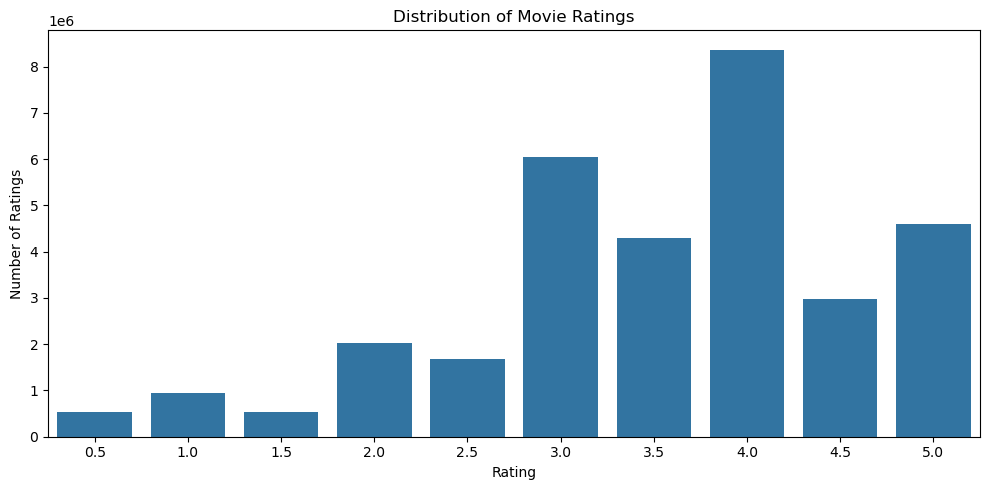

In [12]:
plt.figure(figsize=(10, 5))

sns.countplot(
    data=ratings,
    x="rating"
)

plt.title("Distribution of Movie Ratings")
plt.xlabel("Rating")
plt.ylabel("Number of Ratings")
plt.tight_layout()
plt.show()

In [13]:
plt.savefig(
    OUTPUT_DIR / "rating_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

<Figure size 640x480 with 0 Axes>

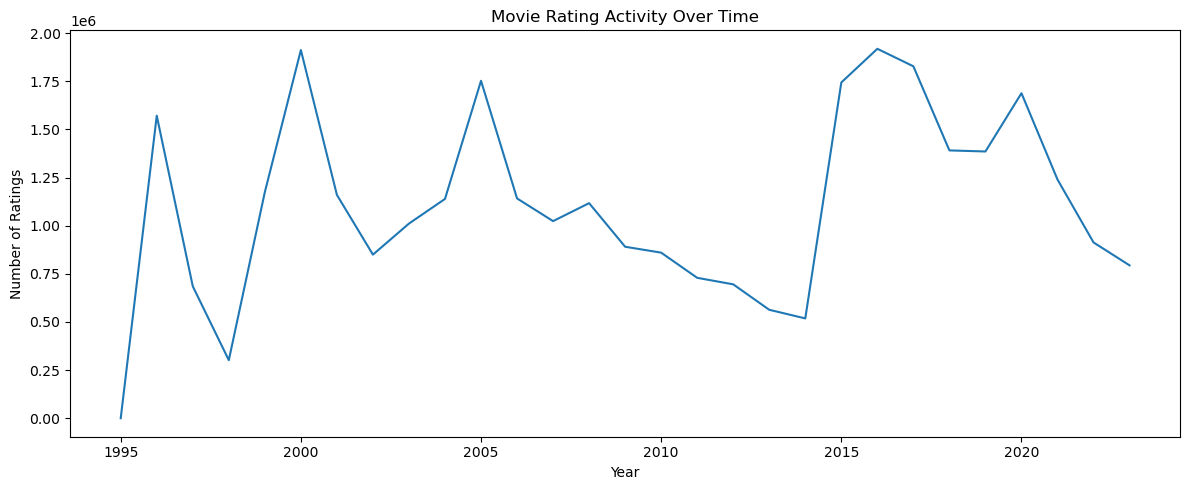

In [14]:
yearly_ratings = (
    ratings.groupby("year")
    .size()
    .reset_index(name="rating_count")
)

plt.figure(figsize=(12, 5))

sns.lineplot(
    data=yearly_ratings,
    x="year",
    y="rating_count"
)

plt.title("Movie Rating Activity Over Time")
plt.xlabel("Year")
plt.ylabel("Number of Ratings")
plt.tight_layout()
plt.show()

In [15]:
yearly_summary = (
    ratings.groupby("year")
    .agg(
        total_ratings=("rating", "size"),
        unique_users=("userId", "nunique"),
        unique_movies=("movieId", "nunique"),
        average_rating=("rating", "mean")
    )
    .reset_index()
)

display(yearly_summary)

,year,total_ratings,unique_users,unique_movies,average_rating
0,1995,4,2,4,3.750000
1,1996,1571368,25305,1386,3.546181
2,1997,685388,11073,1673,3.588809
3,1998,301691,3662,2302,3.514003
4,1999,1174629,9227,3038,3.616688
5,2000,1912322,14668,3876,3.576486
6,2001,1160098,10224,4728,3.533513
7,2002,849762,7788,5737,3.484735
8,2003,1011000,8406,6818,3.473930
9,2004,1139068,8536,7998,3.430688


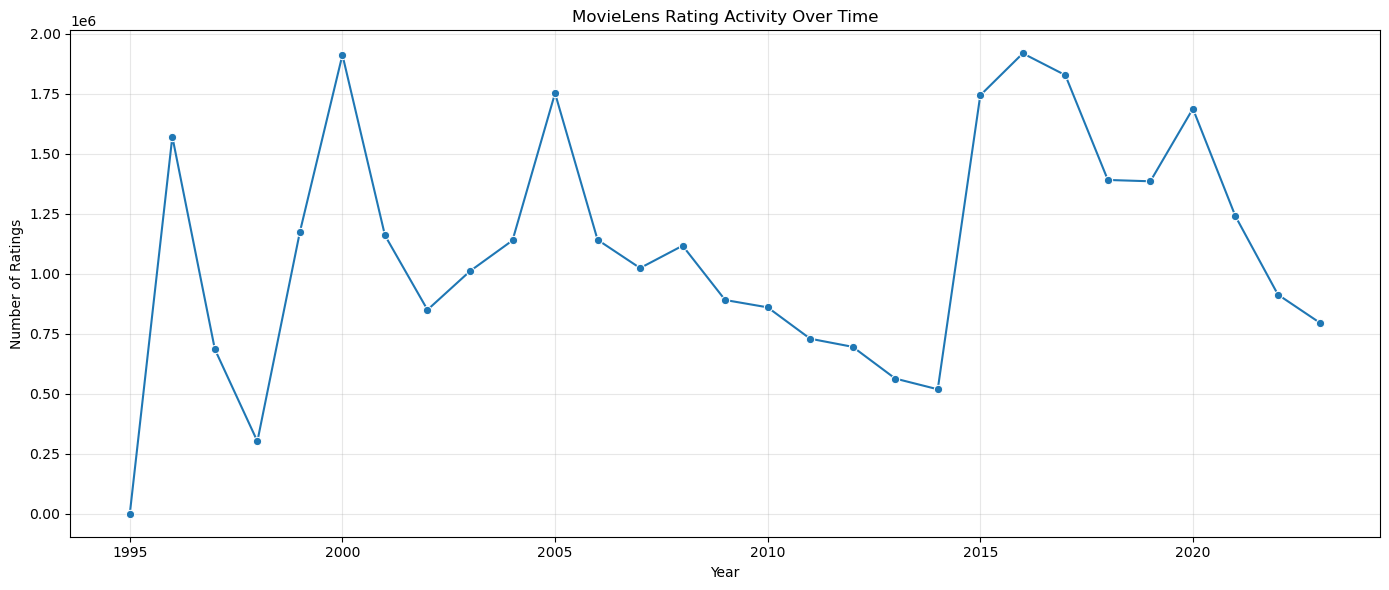

In [16]:
plt.figure(figsize=(14, 6))

sns.lineplot(
    data=yearly_summary,
    x="year",
    y="total_ratings",
    marker="o"
)

plt.title("MovieLens Rating Activity Over Time")
plt.xlabel("Year")
plt.ylabel("Number of Ratings")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [17]:
movies["release_year"] = (
    movies["title"]
    .str.extract(r"\((\d{4})\)$")[0]
    .astype("float")
)

movies[["movieId", "title", "genres", "release_year"]].head(10)

,movieId,title,genres,release_year
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy,1995.0
1,2,Jumanji (1995),Adventure|Children|Fantasy,1995.0
2,3,Grumpier Old Men (1995),Comedy|Romance,1995.0
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance,1995.0
4,5,Father of the Bride Part II (1995),Comedy,1995.0
5,6,Heat (1995),Action|Crime|Thriller,1995.0
6,7,Sabrina (1995),Comedy|Romance,1995.0
7,8,Tom and Huck (1995),Adventure|Children,1995.0
8,9,Sudden Death (1995),Action,1995.0
9,10,GoldenEye (1995),Action|Adventure|Thriller,1995.0


In [18]:
print(
    "Missing release years:",
    movies["release_year"].isna().sum()
)

Missing release years: 771


In [19]:
movies["genre_count"] = (
    movies["genres"]
    .fillna("")
    .apply(
        lambda x: 0 if x == "(no genres listed)" else len(x.split("|"))
    )
)

movies[["title", "genres", "genre_count"]].head(10)

,title,genres,genre_count
0,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy,5
1,Jumanji (1995),Adventure|Children|Fantasy,3
2,Grumpier Old Men (1995),Comedy|Romance,2
3,Waiting to Exhale (1995),Comedy|Drama|Romance,3
4,Father of the Bride Part II (1995),Comedy,1
5,Heat (1995),Action|Crime|Thriller,3
6,Sabrina (1995),Comedy|Romance,2
7,Tom and Huck (1995),Adventure|Children,2
8,Sudden Death (1995),Action,1
9,GoldenEye (1995),Action|Adventure|Thriller,3


In [20]:
ratings["year_month"] = ratings["datetime"].dt.to_period("M")

In [21]:
monthly_activity = (
    ratings
    .groupby(["movieId", "year_month"])
    .agg(
        rating_count=("rating", "size"),
        rating_sum=("rating", "sum"),
        rating_sum_sq=("rating", lambda x: np.square(x).sum()),
        unique_users=("userId", "nunique")
    )
    .reset_index()
)

In [22]:
monthly_activity.head()

,movieId,year_month,rating_count,rating_sum,rating_sum_sq,unique_users
0,1,1996-01,1,4.0,16.0,1
1,1,1996-02,11,49.0,227.0,11
2,1,1996-03,70,321.0,1503.0,70
3,1,1996-04,464,2054.0,9408.0,464
4,1,1996-05,1636,6721.0,28967.0,1636


In [23]:
monthly_activity.shape

(2435432, 6)

In [24]:
monthly_activity.dtypes

movieId              int32
year_month       period[M]
rating_count         int64
rating_sum         float32
rating_sum_sq      float32
unique_users         int64
dtype: object

In [25]:
monthly_activity["avg_rating"] = (
    monthly_activity["rating_sum"] / monthly_activity["rating_count"]
).astype("float32")

monthly_activity.head()

,movieId,year_month,rating_count,rating_sum,rating_sum_sq,unique_users,avg_rating
0,1,1996-01,1,4.0,16.0,1,4.000000
1,1,1996-02,11,49.0,227.0,11,4.454545
2,1,1996-03,70,321.0,1503.0,70,4.585714
3,1,1996-04,464,2054.0,9408.0,464,4.426724
4,1,1996-05,1636,6721.0,28967.0,1636,4.108191


In [26]:
movie_features = movies[
    ["movieId", "title", "genres", "release_year", "genre_count"]
].copy()

monthly_activity = monthly_activity.merge(
    movie_features,
    on="movieId",
    how="left"
)

monthly_activity.head()

,movieId,year_month,rating_count,rating_sum,rating_sum_sq,unique_users,avg_rating,title,genres,release_year,genre_count
0,1,1996-01,1,4.0,16.0,1,4.000000,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy,1995.0,5
1,1,1996-02,11,49.0,227.0,11,4.454545,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy,1995.0,5
2,1,1996-03,70,321.0,1503.0,70,4.585714,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy,1995.0,5
3,1,1996-04,464,2054.0,9408.0,464,4.426724,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy,1995.0,5
4,1,1996-05,1636,6721.0,28967.0,1636,4.108191,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy,1995.0,5


In [27]:
monthly_activity["month"] = monthly_activity["year_month"].dt.to_timestamp()

monthly_activity = monthly_activity.sort_values(
    ["movieId", "month"]
).reset_index(drop=True)

monthly_activity.head()

,movieId,year_month,rating_count,rating_sum,rating_sum_sq,unique_users,avg_rating,title,genres,release_year,genre_count,month
0,1,1996-01,1,4.0,16.0,1,4.000000,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy,1995.0,5,1996-01-01
1,1,1996-02,11,49.0,227.0,11,4.454545,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy,1995.0,5,1996-02-01
2,1,1996-03,70,321.0,1503.0,70,4.585714,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy,1995.0,5,1996-03-01
3,1,1996-04,464,2054.0,9408.0,464,4.426724,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy,1995.0,5,1996-04-01
4,1,1996-05,1636,6721.0,28967.0,1636,4.108191,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy,1995.0,5,1996-05-01


In [28]:
monthly_activity["rating_count_lag1"] = (
    monthly_activity.groupby("movieId")["rating_count"].shift(1)
)

monthly_activity["rating_count_lag2"] = (
    monthly_activity.groupby("movieId")["rating_count"].shift(2)
)

monthly_activity["rating_count_lag3"] = (
    monthly_activity.groupby("movieId")["rating_count"].shift(3)
)

monthly_activity["avg_rating_lag1"] = (
    monthly_activity.groupby("movieId")["avg_rating"].shift(1)
)

monthly_activity["unique_users_lag1"] = (
    monthly_activity.groupby("movieId")["unique_users"].shift(1)
)

In [29]:
monthly_activity["rating_count_3m"] = (
    monthly_activity.groupby("movieId")["rating_count"]
    .transform(lambda x: x.shift(1).rolling(3, min_periods=1).sum())
)

monthly_activity["rating_count_6m"] = (
    monthly_activity.groupby("movieId")["rating_count"]
    .transform(lambda x: x.shift(1).rolling(6, min_periods=1).sum())
)

monthly_activity["users_3m"] = (
    monthly_activity.groupby("movieId")["unique_users"]
    .transform(lambda x: x.shift(1).rolling(3, min_periods=1).sum())
)

In [30]:
monthly_activity["future_rating_count"] = (
    monthly_activity.groupby("movieId")["rating_count"].shift(-1)
)

monthly_activity["future_unique_users"] = (
    monthly_activity.groupby("movieId")["unique_users"].shift(-1)
)

In [31]:
monthly_activity["future_popularity"] = np.log1p(
    monthly_activity["future_rating_count"]
)

In [32]:
model_data = monthly_activity.dropna(
    subset=[
        "rating_count_lag1",
        "rating_count_lag2",
        "rating_count_lag3",
        "avg_rating_lag1",
        "unique_users_lag1",
        "future_popularity"
    ]
).copy()

model_data.shape

(2185695, 23)

In [33]:
model_data[
    [
        "movieId",
        "title",
        "month",
        "rating_count_lag1",
        "rating_count_lag2",
        "rating_count_lag3",
        "avg_rating_lag1",
        "unique_users_lag1",
        "rating_count_3m",
        "rating_count_6m",
        "users_3m",
        "future_rating_count",
        "future_popularity"
    ]
].head(10)

,movieId,title,month,rating_count_lag1,rating_count_lag2,rating_count_lag3,avg_rating_lag1,unique_users_lag1,rating_count_3m,rating_count_6m,users_3m,future_rating_count,future_popularity
3,1,Toy Story (1995),1996-04-01,70.0,11.0,1.0,4.585714,70.0,82.0,82.0,82.0,1636.0,7.400621
4,1,Toy Story (1995),1996-05-01,464.0,70.0,11.0,4.426724,464.0,545.0,546.0,545.0,1712.0,7.446001
5,1,Toy Story (1995),1996-06-01,1636.0,464.0,70.0,4.108191,1636.0,2170.0,2182.0,2170.0,25.0,3.258097
6,1,Toy Story (1995),1996-07-01,1712.0,1636.0,464.0,4.094042,1712.0,3812.0,3894.0,3812.0,24.0,3.218876
7,1,Toy Story (1995),1996-08-01,25.0,1712.0,1636.0,4.360000,25.0,3373.0,3918.0,3373.0,11.0,2.484907
8,1,Toy Story (1995),1996-09-01,24.0,25.0,1712.0,4.208333,24.0,1761.0,3931.0,1761.0,325.0,5.786897
9,1,Toy Story (1995),1996-10-01,11.0,24.0,25.0,4.090909,11.0,60.0,3872.0,60.0,1220.0,7.107425
10,1,Toy Story (1995),1996-11-01,325.0,11.0,24.0,4.190769,325.0,360.0,3733.0,360.0,1421.0,7.259820
11,1,Toy Story (1995),1996-12-01,1220.0,325.0,11.0,4.158197,1220.0,1556.0,3317.0,1556.0,1111.0,7.013915
12,1,Toy Story (1995),1997-01-01,1421.0,1220.0,325.0,4.037298,1421.0,2966.0,3026.0,2966.0,701.0,6.553933


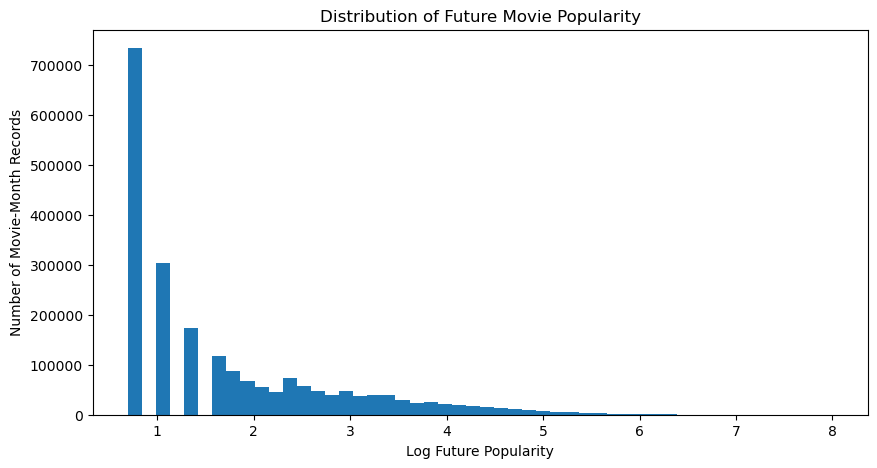

In [34]:
plt.figure(figsize=(10, 5))

plt.hist(
    model_data["future_popularity"],
    bins=50
)

plt.xlabel("Log Future Popularity")
plt.ylabel("Number of Movie-Month Records")
plt.title("Distribution of Future Movie Popularity")

plt.show()

In [35]:
print("Modeling period:")
print("Start:", model_data["month"].min())
print("End:", model_data["month"].max())

print("\nNumber of records:", len(model_data))
print("Number of movies:", model_data["movieId"].nunique())

Modeling period:
Start: 1996-03-01 00:00:00
End: 2023-09-01 00:00:00

Number of records: 2185695
Number of movies: 42195


In [36]:
model_check = monthly_activity.sort_values(
    ["movieId", "month"]
).copy()

model_check["month_gap"] = (
    model_check.groupby("movieId")["month"]
    .diff()
    .dt.days
)

model_check["month_gap"].describe()

count    2.351000e+06
mean     7.687800e+01
std      1.636156e+02
min      2.800000e+01
25%      3.000000e+01
50%      3.100000e+01
75%      6.100000e+01
max      5.936000e+03
Name: month_gap, dtype: float64

In [37]:
print("Total movie-month records:", len(model_check))
print("Records with consecutive months:", (model_check["month_gap"].between(28, 31)).sum())
print("Records with missing month before them:", (~model_check["month_gap"].between(28, 31)).sum())

Total movie-month records: 2435432
Records with consecutive months: 1715818
Records with missing month before them: 719614


In [38]:
monthly_activity = monthly_activity.sort_values(
    ["movieId", "month"]
).reset_index(drop=True)

monthly_activity["month_gap"] = (
    monthly_activity.groupby("movieId")["month"].diff().dt.days
)

monthly_activity["next_month_gap"] = (
    monthly_activity.groupby("movieId")["month"].diff(-1).abs().dt.days
)

In [39]:
monthly_activity["rating_count_lag1"] = (
    monthly_activity.groupby("movieId")["rating_count"].shift(1)
)

monthly_activity["rating_count_lag2"] = (
    monthly_activity.groupby("movieId")["rating_count"].shift(2)
)

monthly_activity["rating_count_lag3"] = (
    monthly_activity.groupby("movieId")["rating_count"].shift(3)
)

monthly_activity["avg_rating_lag1"] = (
    monthly_activity.groupby("movieId")["avg_rating"].shift(1)
)

monthly_activity["unique_users_lag1"] = (
    monthly_activity.groupby("movieId")["unique_users"].shift(1)
)

In [40]:
monthly_activity["rating_count_3m"] = (
    monthly_activity.groupby("movieId")["rating_count"]
    .transform(lambda x: x.shift(1).rolling(3, min_periods=3).sum())
)

monthly_activity["rating_count_6m"] = (
    monthly_activity.groupby("movieId")["rating_count"]
    .transform(lambda x: x.shift(1).rolling(6, min_periods=6).sum())
)

monthly_activity["users_3m"] = (
    monthly_activity.groupby("movieId")["unique_users"]
    .transform(lambda x: x.shift(1).rolling(3, min_periods=3).sum())
)

In [41]:
monthly_activity["future_rating_count"] = (
    monthly_activity.groupby("movieId")["rating_count"].shift(-1)
)

monthly_activity["future_unique_users"] = (
    monthly_activity.groupby("movieId")["unique_users"].shift(-1)
)

In [42]:
model_data = monthly_activity[
    (monthly_activity["month_gap"].between(28, 31)) &
    (monthly_activity["next_month_gap"].between(28, 31))
].copy()

In [43]:
model_data["future_popularity"] = np.log1p(
    model_data["future_rating_count"]
)

In [44]:
required_columns = [
    "rating_count_lag1",
    "rating_count_lag2",
    "rating_count_lag3",
    "avg_rating_lag1",
    "unique_users_lag1",
    "rating_count_3m",
    "rating_count_6m",
    "users_3m",
    "future_rating_count",
    "future_popularity"
]

model_data = model_data.dropna(
    subset=required_columns
).reset_index(drop=True)

print("Final modeling records:", len(model_data))
print("Unique movies:", model_data["movieId"].nunique())
print("Start:", model_data["month"].min())
print("End:", model_data["month"].max())

Final modeling records: 1399774
Unique movies: 21087
Start: 1996-06-01 00:00:00
End: 2023-09-01 00:00:00


In [45]:
model_data[
    [
        "movieId",
        "title",
        "month",
        "rating_count_lag1",
        "rating_count_lag2",
        "rating_count_lag3",
        "avg_rating_lag1",
        "unique_users_lag1",
        "rating_count_3m",
        "rating_count_6m",
        "users_3m",
        "future_rating_count",
        "future_popularity"
    ]
].head(10)

,movieId,title,month,rating_count_lag1,rating_count_lag2,rating_count_lag3,avg_rating_lag1,unique_users_lag1,rating_count_3m,rating_count_6m,users_3m,future_rating_count,future_popularity
0,1,Toy Story (1995),1996-07-01,1712.0,1636.0,464.0,4.094042,1712.0,3812.0,3894.0,3812.0,24.0,3.218876
1,1,Toy Story (1995),1996-08-01,25.0,1712.0,1636.0,4.360000,25.0,3373.0,3918.0,3373.0,11.0,2.484907
2,1,Toy Story (1995),1996-09-01,24.0,25.0,1712.0,4.208333,24.0,1761.0,3931.0,1761.0,325.0,5.786897
3,1,Toy Story (1995),1996-10-01,11.0,24.0,25.0,4.090909,11.0,60.0,3872.0,60.0,1220.0,7.107425
4,1,Toy Story (1995),1996-11-01,325.0,11.0,24.0,4.190769,325.0,360.0,3733.0,360.0,1421.0,7.259820
5,1,Toy Story (1995),1996-12-01,1220.0,325.0,11.0,4.158197,1220.0,1556.0,3317.0,1556.0,1111.0,7.013915
6,1,Toy Story (1995),1997-01-01,1421.0,1220.0,325.0,4.037298,1421.0,2966.0,3026.0,2966.0,701.0,6.553933
7,1,Toy Story (1995),1997-02-01,1111.0,1421.0,1220.0,3.935194,1111.0,3752.0,4112.0,3752.0,1123.0,7.024649
8,1,Toy Story (1995),1997-03-01,701.0,1111.0,1421.0,3.950071,701.0,3233.0,4789.0,3233.0,896.0,6.799056
9,1,Toy Story (1995),1997-04-01,1123.0,701.0,1111.0,3.895815,1123.0,2935.0,5901.0,2935.0,965.0,6.873164


In [46]:
feature_columns = [
    "rating_count_lag1",
    "rating_count_lag2",
    "rating_count_lag3",
    "avg_rating_lag1",
    "unique_users_lag1",
    "rating_count_3m",
    "rating_count_6m",
    "users_3m"
]

target_column = "future_popularity"

print("Features:")
for col in feature_columns:
    print("-", col)

print("\nTarget:")
print("-", target_column)

Features:
- rating_count_lag1
- rating_count_lag2
- rating_count_lag3
- avg_rating_lag1
- unique_users_lag1
- rating_count_3m
- rating_count_6m
- users_3m

Target:
- future_popularity


In [47]:
train_data = model_data[
    model_data["month"] < "2022-01-01"
].copy()

validation_data = model_data[
    (model_data["month"] >= "2022-01-01") &
    (model_data["month"] < "2023-01-01")
].copy()

test_data = model_data[
    model_data["month"] >= "2023-01-01"
].copy()

print("TRAIN:", train_data.shape)
print("VALIDATION:", validation_data.shape)
print("TEST:", test_data.shape)

print("\nTrain period:")
print(train_data["month"].min(), "to", train_data["month"].max())

print("\nValidation period:")
print(validation_data["month"].min(), "to", validation_data["month"].max())

print("\nTest period:")
print(test_data["month"].min(), "to", test_data["month"].max())

TRAIN: (1280540, 25)
VALIDATION: (68103, 25)
TEST: (51131, 25)

Train period:
1996-06-01 00:00:00 to 2021-12-01 00:00:00

Validation period:
2022-01-01 00:00:00 to 2022-12-01 00:00:00

Test period:
2023-01-01 00:00:00 to 2023-09-01 00:00:00


In [48]:
feature_columns = [
    "rating_count_lag1",
    "rating_count_lag2",
    "rating_count_lag3",
    "avg_rating_lag1",
    "unique_users_lag1",
    "rating_count_3m",
    "rating_count_6m",
    "users_3m"
]

target_column = "future_popularity"

X_train = train_data[feature_columns].copy()
y_train = train_data[target_column].copy()

X_validation = validation_data[feature_columns].copy()
y_validation = validation_data[target_column].copy()

X_test = test_data[feature_columns].copy()
y_test = test_data[target_column].copy()

print("X_train:", X_train.shape)
print("y_train:", y_train.shape)
print("X_validation:", X_validation.shape)
print("X_test:", X_test.shape)

X_train: (1280540, 8)
y_train: (1280540,)
X_validation: (68103, 8)
X_test: (51131, 8)


In [49]:
print("Training missing values:")
print(X_train.isnull().sum())

print("\nValidation missing values:")
print(X_validation.isnull().sum())

print("\nTest missing values:")
print(X_test.isnull().sum())

Training missing values:
rating_count_lag1    0
rating_count_lag2    0
rating_count_lag3    0
avg_rating_lag1      0
unique_users_lag1    0
rating_count_3m      0
rating_count_6m      0
users_3m             0
dtype: int64

Validation missing values:
rating_count_lag1    0
rating_count_lag2    0
rating_count_lag3    0
avg_rating_lag1      0
unique_users_lag1    0
rating_count_3m      0
rating_count_6m      0
users_3m             0
dtype: int64

Test missing values:
rating_count_lag1    0
rating_count_lag2    0
rating_count_lag3    0
avg_rating_lag1      0
unique_users_lag1    0
rating_count_3m      0
rating_count_6m      0
users_3m             0
dtype: int64


In [51]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [52]:
baseline_prediction = np.log1p(
    test_data["rating_count_lag1"]
)

baseline_mae = mean_absolute_error(
    y_test,
    baseline_prediction
)

baseline_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        baseline_prediction
    )
)

baseline_r2 = r2_score(
    y_test,
    baseline_prediction
)

print("Baseline Model")
print("--------------------")
print("MAE :", baseline_mae)
print("RMSE:", baseline_rmse)
print("R²  :", baseline_r2)

Baseline Model
--------------------
MAE : 0.3890601044263526
RMSE: 0.520924031153781
R²  : 0.7428637810502773


## Random Forest

In [53]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [54]:
rf_model = RandomForestRegressor(
    n_estimators=100,
    max_depth=15,
    min_samples_leaf=5,
    max_features="sqrt",
    n_jobs=-1,
    random_state=42
)

rf_model.fit(
    X_train,
    y_train
)

,n_estimators,100
,criterion,'squared_error'
,max_depth,15
,min_samples_split,2
,min_samples_leaf,5
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [55]:
rf_validation_pred = rf_model.predict(
    X_validation
)

rf_validation_mae = mean_absolute_error(
    y_validation,
    rf_validation_pred
)

rf_validation_rmse = np.sqrt(
    mean_squared_error(
        y_validation,
        rf_validation_pred
    )
)

rf_validation_r2 = r2_score(
    y_validation,
    rf_validation_pred
)

print("Random Forest - Validation")
print("----------------------------")
print("MAE :", rf_validation_mae)
print("RMSE:", rf_validation_rmse)
print("R²  :", rf_validation_r2)

Random Forest - Validation
----------------------------
MAE : 0.3008502548629695
RMSE: 0.3759853668547299
R²  : 0.863640445720106


In [57]:
rf_test_pred = rf_model.predict(
    X_test
)

rf_test_mae = mean_absolute_error(
    y_test,
    rf_test_pred
)

rf_test_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        rf_test_pred
    )
)

rf_test_r2 = r2_score(
    y_test,
    rf_test_pred
)

print("Random Forest - Test")
print("---------------------")
print("MAE :", rf_test_mae)
print("RMSE:", rf_test_rmse)
print("R²  :", rf_test_r2)

Random Forest - Test
---------------------
MAE : 0.32618511171495046
RMSE: 0.4136542566148348
R²  : 0.8378602632391423


In [58]:
feature_importance = pd.DataFrame({
    "Feature": feature_columns,
    "Importance": rf_model.feature_importances_
}).sort_values(
    "Importance",
    ascending=False
)

feature_importance

,Feature,Importance
5,rating_count_3m,0.261246
7,users_3m,0.205063
6,rating_count_6m,0.155068
0,rating_count_lag1,0.132397
1,rating_count_lag2,0.118775
4,unique_users_lag1,0.093322
2,rating_count_lag3,0.030920
3,avg_rating_lag1,0.003209


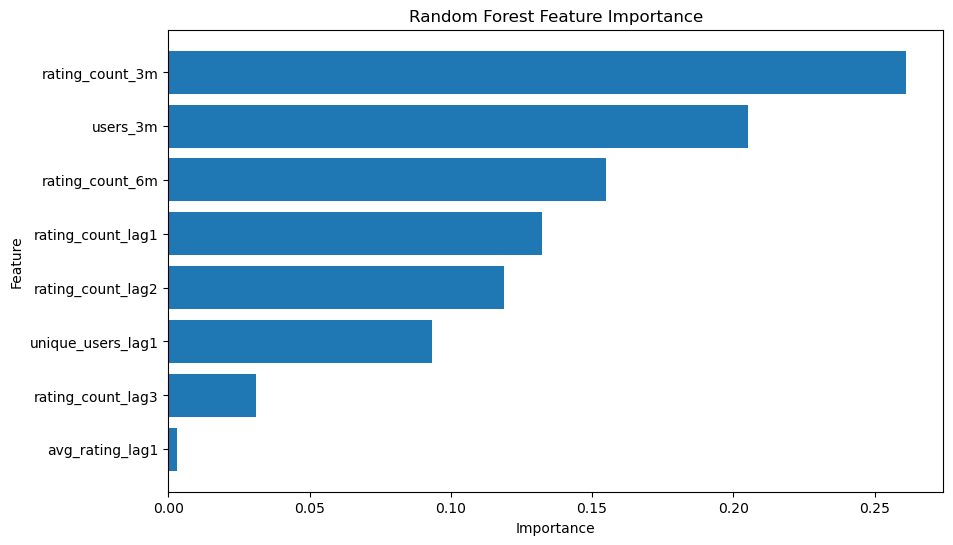

In [59]:
plt.figure(figsize=(10, 6))

plt.barh(
    feature_importance["Feature"],
    feature_importance["Importance"]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Random Forest Feature Importance")
plt.gca().invert_yaxis()

plt.show()

## XGBoost

In [60]:
from xgboost import XGBRegressor

In [61]:
xgb_model = XGBRegressor(
    n_estimators=300,
    max_depth=8,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="reg:squarederror",
    n_jobs=-1,
    random_state=42
)

xgb_model.fit(
    X_train,
    y_train,
    eval_set=[(X_validation, y_validation)],
    verbose=False
)

,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.8
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [62]:
xgb_validation_pred = xgb_model.predict(
    X_validation
)

xgb_validation_mae = mean_absolute_error(
    y_validation,
    xgb_validation_pred
)

xgb_validation_rmse = np.sqrt(
    mean_squared_error(
        y_validation,
        xgb_validation_pred
    )
)

xgb_validation_r2 = r2_score(
    y_validation,
    xgb_validation_pred
)

print("XGBoost - Validation")
print("----------------------")
print("MAE :", xgb_validation_mae)
print("RMSE:", xgb_validation_rmse)
print("R²  :", xgb_validation_r2)

XGBoost - Validation
----------------------
MAE : 0.29997220729462715
RMSE: 0.3748771041927185
R²  : 0.8644431337519842


In [63]:
xgb_test_pred = xgb_model.predict(
    X_test
)

xgb_test_mae = mean_absolute_error(
    y_test,
    xgb_test_pred
)

xgb_test_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        xgb_test_pred
    )
)

xgb_test_r2 = r2_score(
    y_test,
    xgb_test_pred
)

print("XGBoost - Test")
print("----------------")
print("MAE :", xgb_test_mae)
print("RMSE:", xgb_test_rmse)
print("R²  :", xgb_test_r2)

XGBoost - Test
----------------
MAE : 0.3255154971329086
RMSE: 0.412944859767608
R²  : 0.8384159098361417


In [64]:
comparison = pd.DataFrame({
    "Model": [
        "Baseline",
        "Random Forest",
        "XGBoost"
    ],
    "MAE": [
        baseline_mae,
        rf_test_mae,
        xgb_test_mae
    ],
    "RMSE": [
        baseline_rmse,
        rf_test_rmse,
        xgb_test_rmse
    ],
    "R2": [
        baseline_r2,
        rf_test_r2,
        xgb_test_r2
    ]
})

comparison

,Model,MAE,RMSE,R2
0,Baseline,0.389060,0.520924,0.742864
1,Random Forest,0.326185,0.413654,0.837860
2,XGBoost,0.325515,0.412945,0.838416


In [65]:
comparison.sort_values(
    "RMSE",
    ascending=True
)

,Model,MAE,RMSE,R2
2,XGBoost,0.325515,0.412945,0.838416
1,Random Forest,0.326185,0.413654,0.837860
0,Baseline,0.389060,0.520924,0.742864


In [66]:
error_analysis = test_data[
    [
        "movieId",
        "title",
        "month",
        "future_rating_count"
    ]
].copy()

error_analysis["actual_log_popularity"] = y_test.values
error_analysis["predicted_log_popularity"] = xgb_test_pred

error_analysis["actual_rating_count"] = np.expm1(
    error_analysis["actual_log_popularity"]
)

error_analysis["predicted_rating_count"] = np.expm1(
    error_analysis["predicted_log_popularity"]
)

error_analysis["absolute_error"] = abs(
    error_analysis["actual_rating_count"] -
    error_analysis["predicted_rating_count"]
)

error_analysis.head(10)

,movieId,title,month,future_rating_count,actual_log_popularity,predicted_log_popularity,actual_rating_count,predicted_rating_count,absolute_error
315,1,Toy Story (1995),2023-01-01,92.0,4.532599,4.294690,92.0,72.309464,19.690536
316,1,Toy Story (1995),2023-02-01,117.0,4.770685,4.561397,117.0,94.717110,22.282890
317,1,Toy Story (1995),2023-03-01,93.0,4.543295,4.520622,93.0,90.892715,2.107285
318,1,Toy Story (1995),2023-04-01,104.0,4.653960,4.666970,104.0,105.374916,1.374916
319,1,Toy Story (1995),2023-05-01,87.0,4.477337,4.570349,87.0,95.577827,8.577827
320,1,Toy Story (1995),2023-06-01,116.0,4.762174,4.614260,116.0,99.913147,16.086853
321,1,Toy Story (1995),2023-07-01,132.0,4.890349,4.485574,132.0,87.727844,44.272156
322,1,Toy Story (1995),2023-08-01,116.0,4.762174,4.670516,116.0,105.752869,10.247131
323,1,Toy Story (1995),2023-09-01,28.0,3.367296,4.788684,28.0,119.143143,91.143143
639,2,Jumanji (1995),2023-01-01,40.0,3.713572,3.605744,40.0,35.809063,4.190937


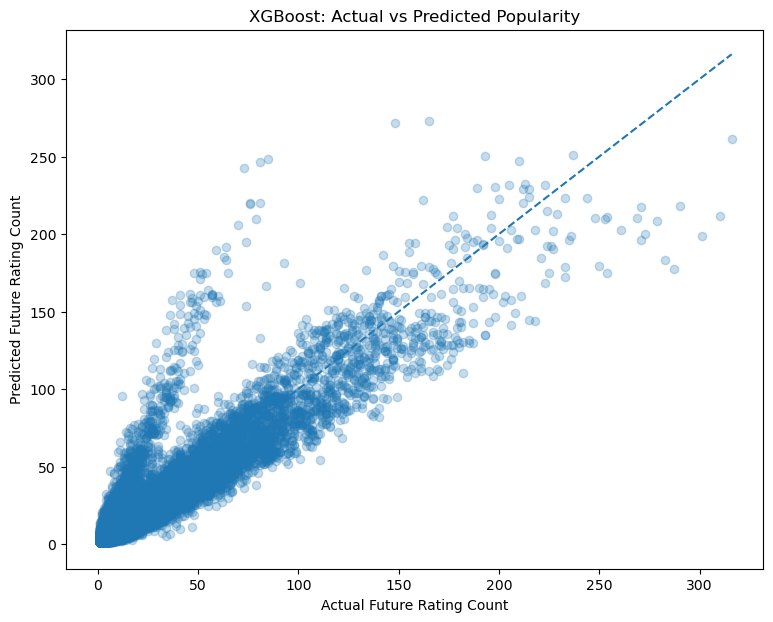

In [67]:
plt.figure(figsize=(9, 7))

plt.scatter(
    error_analysis["actual_rating_count"],
    error_analysis["predicted_rating_count"],
    alpha=0.25
)

max_value = max(
    error_analysis["actual_rating_count"].max(),
    error_analysis["predicted_rating_count"].max()
)

plt.plot(
    [0, max_value],
    [0, max_value],
    linestyle="--"
)

plt.xlabel("Actual Future Rating Count")
plt.ylabel("Predicted Future Rating Count")
plt.title("XGBoost: Actual vs Predicted Popularity")

plt.show()

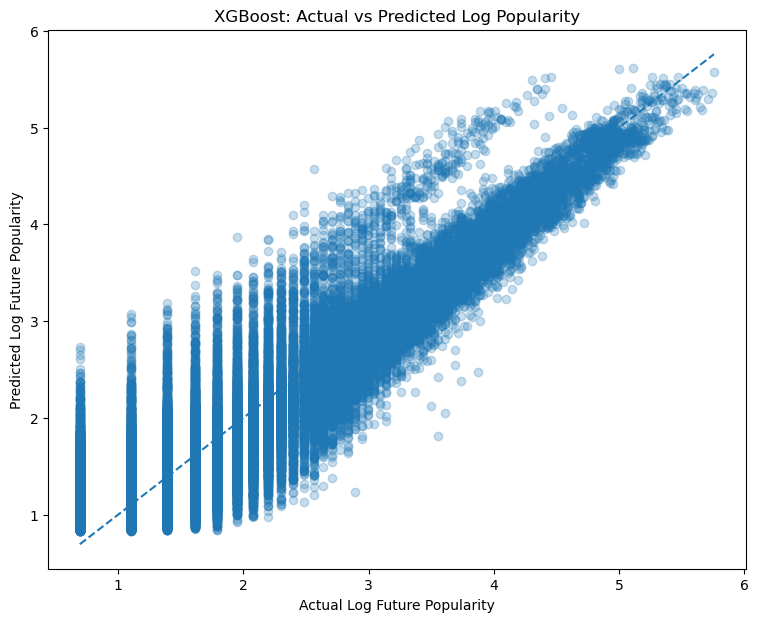

In [68]:
plt.figure(figsize=(9, 7))

plt.scatter(
    error_analysis["actual_log_popularity"],
    error_analysis["predicted_log_popularity"],
    alpha=0.25
)

min_value = min(
    error_analysis["actual_log_popularity"].min(),
    error_analysis["predicted_log_popularity"].min()
)

max_value = max(
    error_analysis["actual_log_popularity"].max(),
    error_analysis["predicted_log_popularity"].max()
)

plt.plot(
    [min_value, max_value],
    [min_value, max_value],
    linestyle="--"
)

plt.xlabel("Actual Log Future Popularity")
plt.ylabel("Predicted Log Future Popularity")
plt.title("XGBoost: Actual vs Predicted Log Popularity")

plt.show()

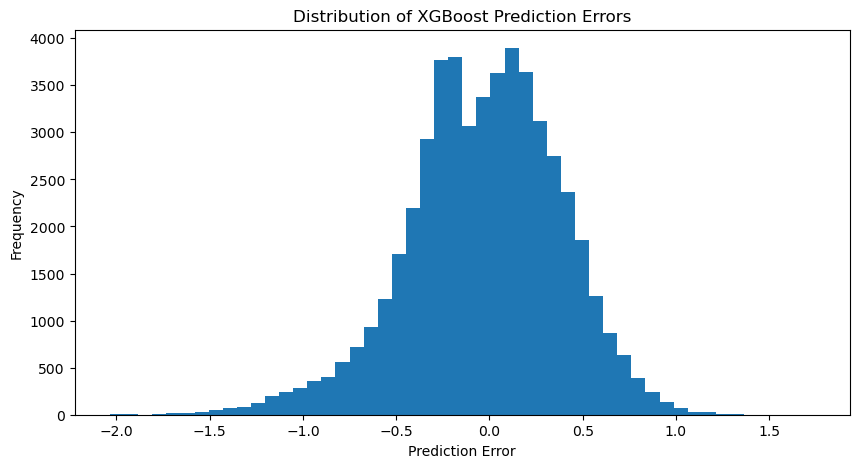

In [69]:
error_analysis["error"] = (
    error_analysis["actual_log_popularity"] -
    error_analysis["predicted_log_popularity"]
)

plt.figure(figsize=(10, 5))

plt.hist(
    error_analysis["error"],
    bins=50
)

plt.xlabel("Prediction Error")
plt.ylabel("Frequency")
plt.title("Distribution of XGBoost Prediction Errors")

plt.show()

In [70]:
largest_errors = error_analysis.sort_values(
    "absolute_error",
    ascending=False
).head(20)

largest_errors[
    [
        "movieId",
        "title",
        "month",
        "actual_rating_count",
        "predicted_rating_count",
        "absolute_error"
    ]
]

,movieId,title,month,actual_rating_count,predicted_rating_count,absolute_error
1261193,109487,Interstellar (2014),2023-09-01,73.0,242.519333,169.519333
1081951,58559,"Dark Knight, The (2008)",2023-09-01,81.0,246.616653,165.616653
1160081,79132,Inception (2010),2023-09-01,85.0,248.546249,163.546249
59353,318,"Shawshank Redemption, The (1994)",2023-09-01,76.0,220.168808,144.168808
414086,2571,"Matrix, The (1999)",2023-09-01,76.0,219.646347,143.646347
466690,2959,Fight Club (1999),2023-09-01,81.0,220.168808,139.168808
760101,5952,"Lord of the Rings: The Two Towers, The (2002)",2023-09-01,70.0,206.062103,136.062103
691055,4993,"Lord of the Rings: The Fellowship of the Ring,...",2023-09-01,79.0,209.969009,130.969009
67043,356,Forrest Gump (1994),2023-09-01,59.0,189.511215,130.511215
55197,296,Pulp Fiction (1994),2023-09-01,64.0,191.877335,127.877335


In [71]:
xgb_importance = pd.DataFrame({
    "Feature": feature_columns,
    "Importance": xgb_model.feature_importances_
}).sort_values(
    "Importance",
    ascending=False
)

xgb_importance

,Feature,Importance
7,users_3m,0.396889
5,rating_count_3m,0.314742
6,rating_count_6m,0.270665
0,rating_count_lag1,0.007627
4,unique_users_lag1,0.005325
2,rating_count_lag3,0.002380
1,rating_count_lag2,0.001459
3,avg_rating_lag1,0.000913


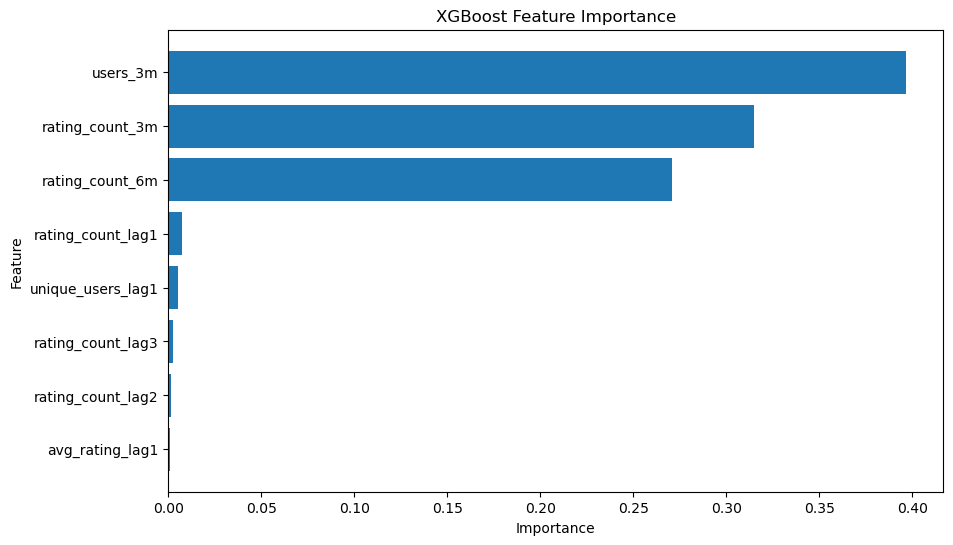

In [72]:
plt.figure(figsize=(10, 6))

plt.barh(
    xgb_importance["Feature"],
    xgb_importance["Importance"]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("XGBoost Feature Importance")

plt.gca().invert_yaxis()

plt.show()

In [73]:
import joblib

model_package = {
    "model": xgb_model,
    "features": feature_columns,
    "target": target_column,
    "target_transformation": "log1p",
    "inverse_transformation": "expm1"
}

joblib.dump(
    model_package,
    "streamiq_xgboost_model.pkl"
)

print("Model saved successfully.")

Model saved successfully.


In [74]:
import joblib

streamiq_model_package = {
    "model": xgb_model,
    "features": feature_columns,
    "target": target_column,
    "target_transformation": "log1p",
    "inverse_transformation": "expm1",
    "model_name": "XGBoost",
    "test_mae": xgb_test_mae,
    "test_rmse": xgb_test_rmse,
    "test_r2": xgb_test_r2
}

joblib.dump(
    streamiq_model_package,
    "streamiq_xgboost_model.pkl"
)

print("STREAMIQ model saved successfully.")

STREAMIQ model saved successfully.


In [75]:
import os

model_path = "streamiq_xgboost_model.pkl"

print("File exists:", os.path.exists(model_path))
print("File size:", round(os.path.getsize(model_path) / (1024 * 1024), 2), "MB")

File exists: True
File size: 4.17 MB


In [76]:
loaded_package = joblib.load(
    "streamiq_xgboost_model.pkl"
)

loaded_model = loaded_package["model"]
loaded_features = loaded_package["features"]

print("Model loaded successfully.")
print("Model:", loaded_package["model_name"])
print("Features:", loaded_features)
print("Test R²:", loaded_package["test_r2"])

Model loaded successfully.
Model: XGBoost
Features: ['rating_count_lag1', 'rating_count_lag2', 'rating_count_lag3', 'avg_rating_lag1', 'unique_users_lag1', 'rating_count_3m', 'rating_count_6m', 'users_3m']
Test R²: 0.8384159098361417


In [77]:
movie_lookup = (
    model_data[
        [
            "movieId",
            "title",
            "month",
            "rating_count_lag1",
            "rating_count_lag2",
            "rating_count_lag3",
            "avg_rating_lag1",
            "unique_users_lag1",
            "rating_count_3m",
            "rating_count_6m",
            "users_3m",
            "future_rating_count",
            "future_popularity"
        ]
    ]
    .copy()
)

movie_lookup = movie_lookup.sort_values(
    ["title", "month"]
).reset_index(drop=True)

print("Movie lookup records:", len(movie_lookup))
print("Unique movies:", movie_lookup["movieId"].nunique())
print("Date range:", movie_lookup["month"].min(), "to", movie_lookup["month"].max())

movie_lookup.head()

Movie lookup records: 1399774
Unique movies: 21087
Date range: 1996-06-01 00:00:00 to 2023-09-01 00:00:00


,movieId,title,month,rating_count_lag1,rating_count_lag2,rating_count_lag3,avg_rating_lag1,unique_users_lag1,rating_count_3m,rating_count_6m,users_3m,future_rating_count,future_popularity
0,210479,(2019),2020-09-01,1.0,2.0,2.0,3.0,1.0,5.0,13.0,5.0,5.0,1.791759
1,210479,(2019),2020-10-01,1.0,1.0,2.0,2.5,1.0,4.0,12.0,4.0,1.0,0.693147
2,210479,(2019),2023-04-01,1.0,1.0,1.0,3.0,1.0,3.0,8.0,3.0,1.0,0.693147
3,51372,"""Great Performances"" Cats (1998)",2009-07-01,2.0,2.0,3.0,1.0,2.0,7.0,20.0,7.0,2.0,1.098612
4,51372,"""Great Performances"" Cats (1998)",2009-08-01,1.0,2.0,2.0,0.5,1.0,5.0,14.0,5.0,2.0,1.098612


In [78]:
movie_lookup.to_csv(
    "streamiq_movie_lookup.csv",
    index=False
)

print("Movie lookup dataset saved successfully.")

Movie lookup dataset saved successfully.


In [79]:
import os

lookup_path = "streamiq_movie_lookup.csv"

print("File exists:", os.path.exists(lookup_path))
print(
    "File size:",
    round(os.path.getsize(lookup_path) / (1024 * 1024), 2),
    "MB"
)

File exists: True
File size: 142.37 MB


In [80]:
deployment_columns = [
    "movieId",
    "title",
    "month",
    "rating_count_lag1",
    "rating_count_lag2",
    "rating_count_lag3",
    "avg_rating_lag1",
    "unique_users_lag1",
    "rating_count_3m",
    "rating_count_6m",
    "users_3m"
]

streamlit_data = movie_lookup[
    deployment_columns
].copy()

streamlit_data = streamlit_data.sort_values(
    ["title", "month"]
).reset_index(drop=True)

print("Deployment records:", len(streamlit_data))
print("Unique movies:", streamlit_data["movieId"].nunique())
print("Features:", len(deployment_columns) - 3)

Deployment records: 1399774
Unique movies: 21087
Features: 8


In [81]:
streamlit_data.to_csv(
    "streamiq_streamlit_data.csv",
    index=False
)

print("STREAMIQ deployment dataset saved successfully.")

STREAMIQ deployment dataset saved successfully.


In [82]:
def predict_movie_popularity(row, model):
    feature_values = row[feature_columns].astype(float).values.reshape(1, -1)

    predicted_log = model.predict(feature_values)[0]

    predicted_count = np.expm1(predicted_log)

    return max(0, predicted_count)

In [83]:
test_row = streamlit_data.iloc[0]

prediction = predict_movie_popularity(
    test_row,
    loaded_model
)

print("Movie:", test_row["title"])
print("Month:", test_row["month"])
print("Predicted next-month rating activity:", round(prediction, 2))

Movie:  (2019)
Month: 2020-09-01 00:00:00
Predicted next-month rating activity: 2.05


In [84]:
search_result = streamlit_data[
    streamlit_data["title"].str.contains(
        "Toy Story",
        case=False,
        na=False
    )
]

search_result[
    [
        "movieId",
        "title",
        "month"
    ]
].tail(10)

,movieId,title,month
1280348,106022,Toy Story of Terror (2013),2022-02-01
1280349,106022,Toy Story of Terror (2013),2022-03-01
1280350,106022,Toy Story of Terror (2013),2022-04-01
1280351,106022,Toy Story of Terror (2013),2022-08-01
1280352,106022,Toy Story of Terror (2013),2022-09-01
1280353,106022,Toy Story of Terror (2013),2022-10-01
1280354,106022,Toy Story of Terror (2013),2022-11-01
1280355,106022,Toy Story of Terror (2013),2023-06-01
1280356,106022,Toy Story of Terror (2013),2023-07-01
1280357,106022,Toy Story of Terror (2013),2023-08-01


In [85]:
toy_story = search_result.iloc[-1]

toy_prediction = predict_movie_popularity(
    toy_story,
    loaded_model
)

print("Movie:", toy_story["title"])
print("Analysis Month:", toy_story["month"])
print(
    "Predicted Next-Month Rating Activity:",
    round(toy_prediction, 2)
)

Movie: Toy Story of Terror (2013)
Analysis Month: 2023-08-01 00:00:00
Predicted Next-Month Rating Activity: 1.53


In [86]:
popularity_thresholds = np.percentile(
    np.expm1(y_train),
    [50, 75, 90]
)

print("50th percentile:", popularity_thresholds[0])
print("75th percentile:", popularity_thresholds[1])
print("90th percentile:", popularity_thresholds[2])

50th percentile: 5.999999999999999
75th percentile: 17.999999999999996
90th percentile: 48.99999999999999


In [87]:
def popularity_label(predicted_count, thresholds):
    p50, p75, p90 = thresholds

    if predicted_count >= p90:
        return "Very High"
    elif predicted_count >= p75:
        return "High"
    elif predicted_count >= p50:
        return "Moderate"
    else:
        return "Low" 

In [88]:
label = popularity_label(
    toy_prediction,
    popularity_thresholds
)

print("Popularity Outlook:", label)

Popularity Outlook: Low


In [89]:
joblib.dump(
    popularity_thresholds,
    "streamiq_popularity_thresholds.pkl"
)

print("Popularity thresholds saved.")

Popularity thresholds saved.


In [90]:
def predict_movie(movie_id, analysis_month):
    data = streamlit_data.copy()

    data["month"] = pd.to_datetime(data["month"])

    selected = data[
        (data["movieId"] == movie_id) &
        (data["month"] == pd.to_datetime(analysis_month))
    ]

    if selected.empty:
        return None

    row = selected.iloc[0]

    X_input = pd.DataFrame(
        [[
            row["rating_count_lag1"],
            row["rating_count_lag2"],
            row["rating_count_lag3"],
            row["avg_rating_lag1"],
            row["unique_users_lag1"],
            row["rating_count_3m"],
            row["rating_count_6m"],
            row["users_3m"]
        ]],
        columns=feature_columns
    )

    predicted_log = loaded_model.predict(X_input)[0]

    predicted_count = np.expm1(predicted_log)

    label = popularity_label(
        predicted_count,
        popularity_thresholds
    )

    return {
        "movieId": row["movieId"],
        "title": row["title"],
        "month": row["month"],
        "predicted_rating_count": predicted_count,
        "popularity_outlook": label
    }

In [91]:
toy_story_data = streamlit_data[
    streamlit_data["title"].str.contains(
        "Toy Story",
        case=False,
        na=False
    )
]

toy_story_data[
    ["movieId", "title", "month"]
].tail(10)

,movieId,title,month
1280348,106022,Toy Story of Terror (2013),2022-02-01
1280349,106022,Toy Story of Terror (2013),2022-03-01
1280350,106022,Toy Story of Terror (2013),2022-04-01
1280351,106022,Toy Story of Terror (2013),2022-08-01
1280352,106022,Toy Story of Terror (2013),2022-09-01
1280353,106022,Toy Story of Terror (2013),2022-10-01
1280354,106022,Toy Story of Terror (2013),2022-11-01
1280355,106022,Toy Story of Terror (2013),2023-06-01
1280356,106022,Toy Story of Terror (2013),2023-07-01
1280357,106022,Toy Story of Terror (2013),2023-08-01


In [92]:
toy_story_data = streamlit_data[
    streamlit_data["title"].eq("Toy Story (1995)")
]

toy_story_data[
    ["movieId", "title", "month"]
].tail(10)

,movieId,title,month
1279625,1,Toy Story (1995),2022-12-01
1279626,1,Toy Story (1995),2023-01-01
1279627,1,Toy Story (1995),2023-02-01
1279628,1,Toy Story (1995),2023-03-01
1279629,1,Toy Story (1995),2023-04-01
1279630,1,Toy Story (1995),2023-05-01
1279631,1,Toy Story (1995),2023-06-01
1279632,1,Toy Story (1995),2023-07-01
1279633,1,Toy Story (1995),2023-08-01
1279634,1,Toy Story (1995),2023-09-01


In [93]:
toy_story_row = toy_story_data.iloc[-1]

print("Movie:", toy_story_row["title"])
print("Movie ID:", toy_story_row["movieId"])
print("Analysis Month:", toy_story_row["month"])

Movie: Toy Story (1995)
Movie ID: 1
Analysis Month: 2023-09-01 00:00:00


In [94]:
result = predict_movie(
    int(toy_story_row["movieId"]),
    toy_story_row["month"]
)

result

{'movieId': np.int32(1),
 'title': 'Toy Story (1995)',
 'month': Timestamp('2023-09-01 00:00:00'),
 'predicted_rating_count': np.float32(119.14314),
 'popularity_outlook': 'Very High'}